🎯 Цель проекта

Понять, какие рекламные кампании наиболее эффективны и как можно увеличить их результативность.
Будем анализировать:

- Как возраст, пол и интересы влияют на клики и конверсии
- Какие кампании приносят больше результата за меньшие деньги
- Где возможны точки роста

In [1]:
import pandas as pd
import numpy as np
# Загрузка данных
df = pd.read_csv("data/KAG_conversion_data.csv")  # Замени на путь к своему файлу

# Смотрим первые строки
print(df.head())

    ad_id  xyz_campaign_id  fb_campaign_id    age gender  interest  \
0  708746              916          103916  30-34      M        15   
1  708749              916          103917  30-34      M        16   
2  708771              916          103920  30-34      M        20   
3  708815              916          103928  30-34      M        28   
4  708818              916          103928  30-34      M        28   

   Impressions  Clicks  Spent  Total_Conversion  Approved_Conversion  
0         7350       1   1.43                 2                    1  
1        17861       2   1.82                 2                    0  
2          693       0   0.00                 1                    0  
3         4259       1   1.25                 1                    0  
4         4133       1   1.29                 1                    1  


In [2]:
# Информация о типах данных
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   object 
 4   gender               1143 non-null   object 
 5   interest             1143 non-null   int64  
 6   Impressions          1143 non-null   int64  
 7   Clicks               1143 non-null   int64  
 8   Spent                1143 non-null   float64
 9   Total_Conversion     1143 non-null   int64  
 10  Approved_Conversion  1143 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 98.4+ KB
None


In [3]:
# Проверка пропусков
print(df.isnull().sum())

ad_id                  0
xyz_campaign_id        0
fb_campaign_id         0
age                    0
gender                 0
interest               0
Impressions            0
Clicks                 0
Spent                  0
Total_Conversion       0
Approved_Conversion    0
dtype: int64


In [4]:
# CTR (Click Through Rate)
df["CTR"] = df["Clicks"] / df["Impressions"]

# CPC (Cost Per Click)
df['CPC'] = df.apply(lambda row: row['Spent'] / row['Clicks'] if row['Clicks'] > 0 else np.nan, axis=1)

# CPA (Cost Per Acquisition)
df['CPA'] = df.apply(lambda row: row['Spent'] / row['Approved_Conversion'] if row['Approved_Conversion'] > 0 else np.nan, axis=1)

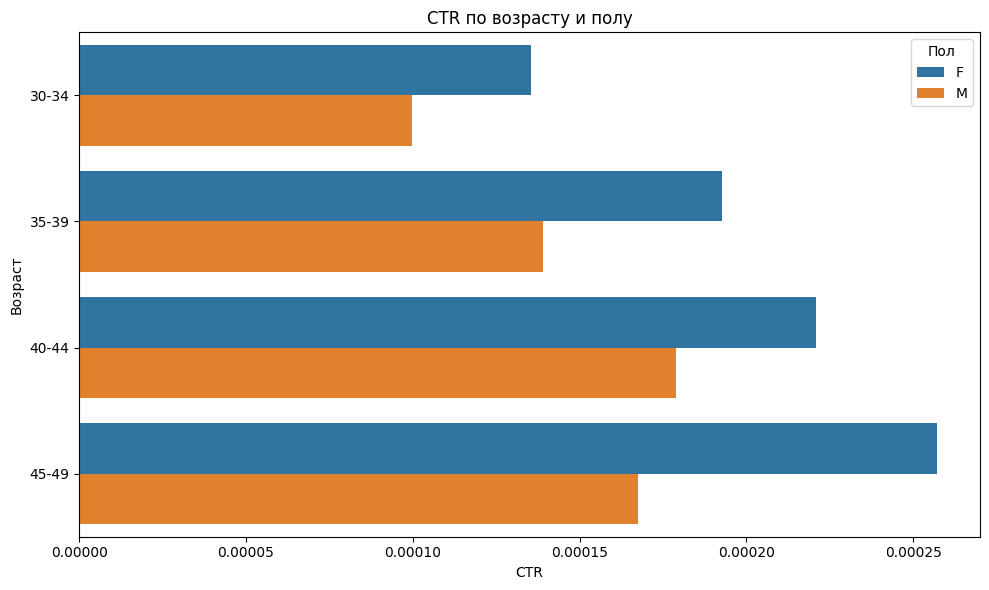

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Группировка
grouped = df.groupby(['age', 'gender'])['CTR'].mean().reset_index()

# Построим barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, x='CTR', y='age', hue='gender')
plt.title('CTR по возрасту и полу')
plt.xlabel('CTR')
plt.ylabel('Возраст')
plt.legend(title='Пол')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_22544\3055049359.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=interest_cpc, x='interest', y='CPC', palette='viridis')


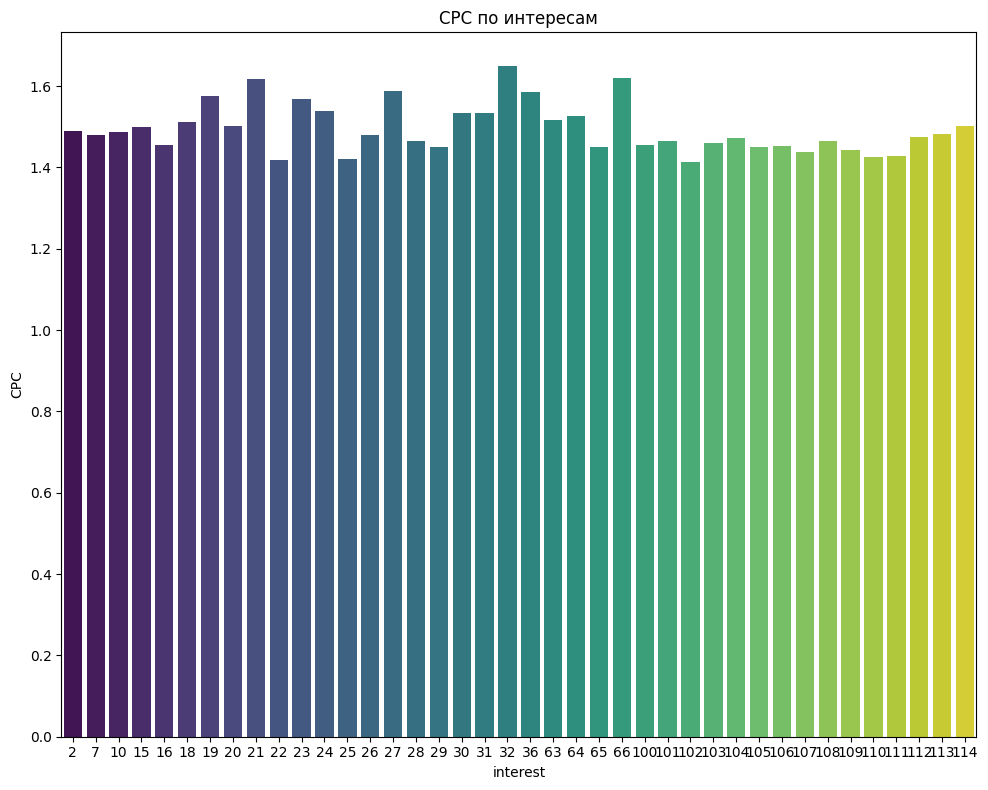

In [6]:
# Средний CPC по интересам
interest_cpc = df.groupby('interest')['CPC'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(data=interest_cpc, x='interest', y='CPC', palette='viridis')
plt.title('CPC по интересам')
plt.xlabel('interest')
plt.ylabel('CPC')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_22544\910837560.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_campaigns, x='fb_campaign_id', y='CTR', palette='mako')


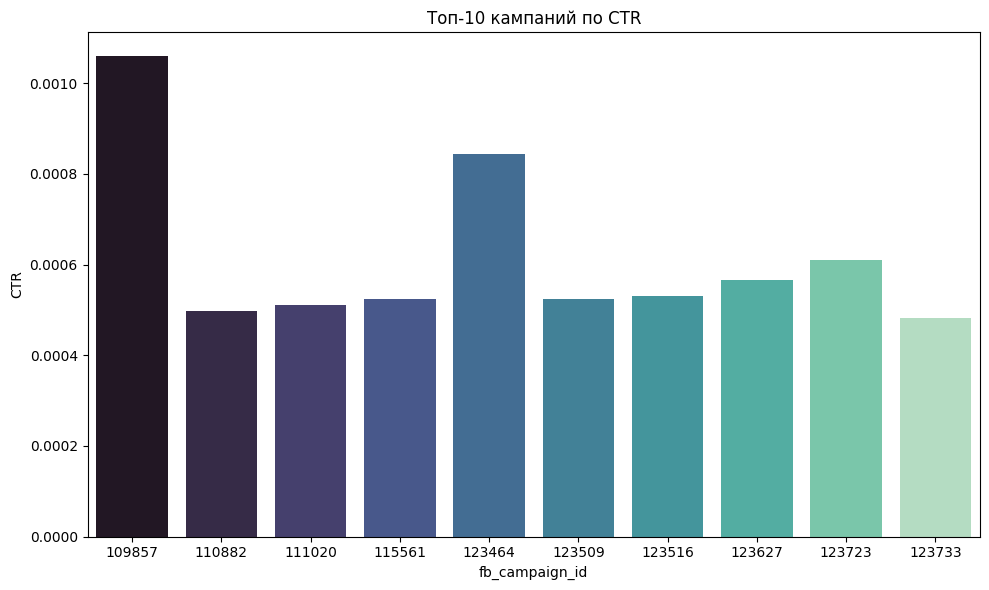

In [7]:
top_campaigns = df.groupby('fb_campaign_id')['CTR'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_campaigns, x='fb_campaign_id', y='CTR', palette='mako')
plt.title('Топ-10 кампаний по CTR')
plt.xlabel('fb_campaign_id')
plt.ylabel('CTR')
plt.tight_layout()
plt.show()

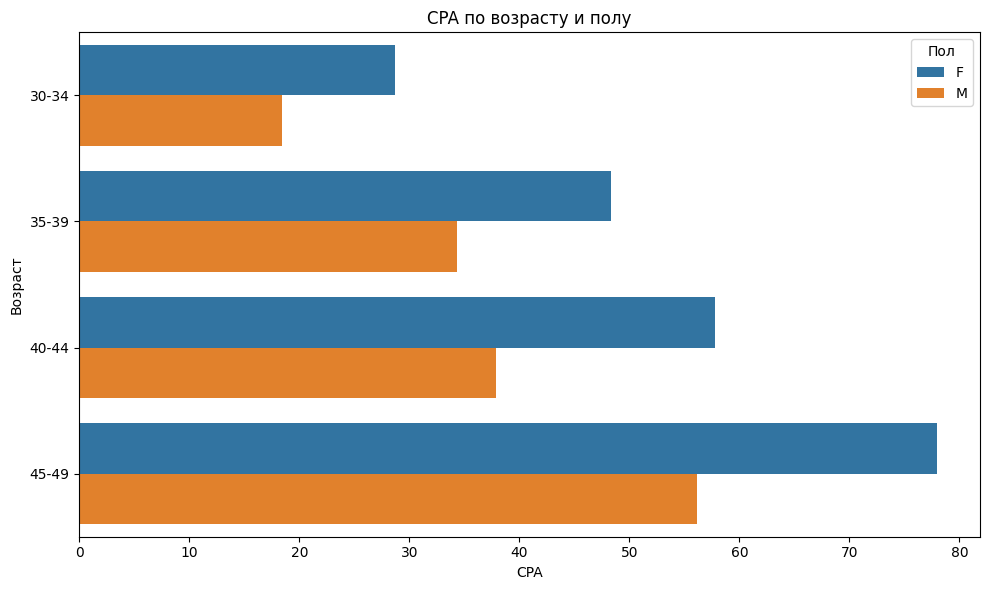

In [8]:
cpa_by_age_gender = df.groupby(['age', 'gender'])['CPA'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=cpa_by_age_gender, x='CPA', y='age', hue='gender')
plt.title('CPA по возрасту и полу')
plt.xlabel('CPA')
plt.ylabel('Возраст')
plt.legend(title='Пол')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_22544\406383820.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=conv_by_interest, x='interest', y='Approved_Conversion', palette='cubehelix')


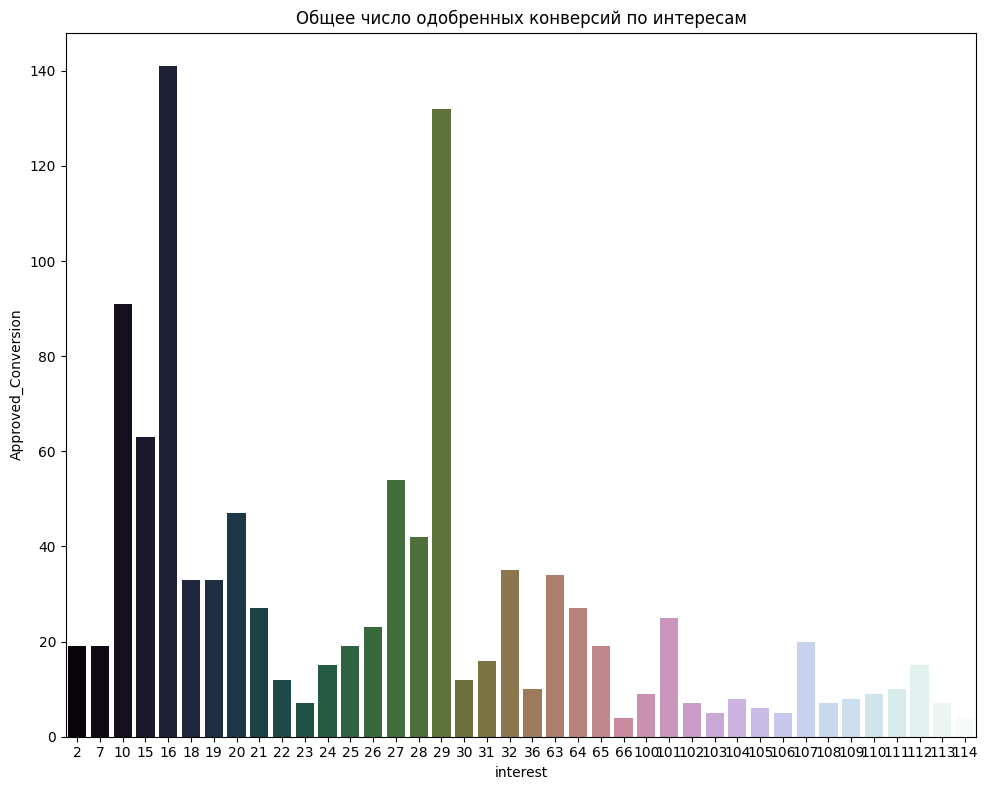

In [9]:
conv_by_interest = df.groupby('interest')['Approved_Conversion'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(data=conv_by_interest, x='interest', y='Approved_Conversion', palette='cubehelix')
plt.title('Общее число одобренных конверсий по интересам')
plt.xlabel('interest')
plt.ylabel('Approved_Conversion')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_22544\1086542067.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_cpa, x='fb_campaign_id', y='CPA', palette='Reds_r')


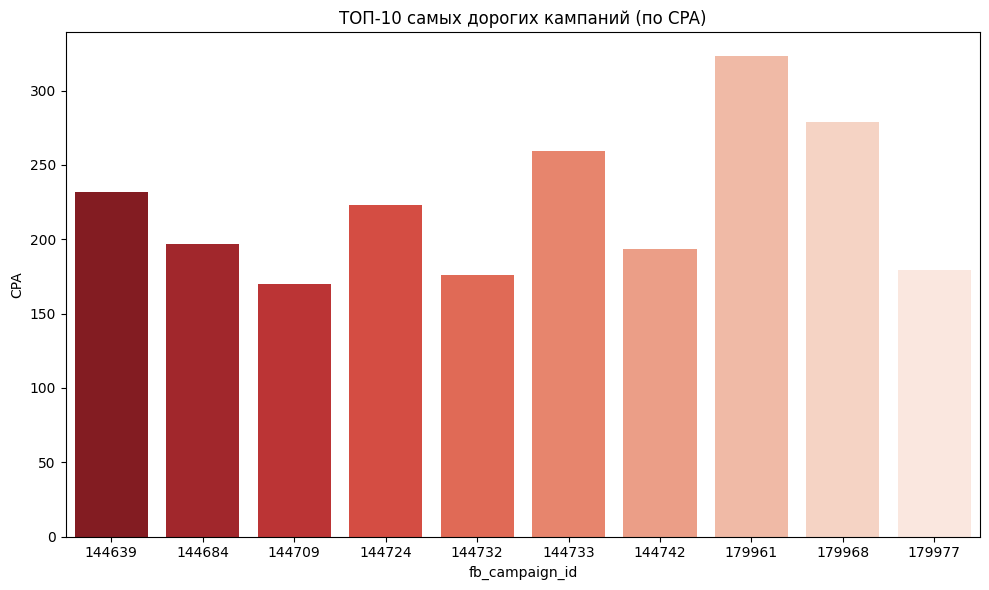

In [10]:
worst_cpa = df.groupby('fb_campaign_id')['CPA'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=worst_cpa, x='fb_campaign_id', y='CPA', palette='Reds_r')
plt.title('ТОП-10 самых дорогих кампаний (по CPA)')
plt.xlabel('fb_campaign_id')
plt.ylabel('CPA')
plt.tight_layout()
plt.show()

In [14]:
#saving data
df.to_csv("data/ForBI.csv", index=False)

📌 Выводы по аналитике рекламных кампаний (Facebook Ads)
1. CTR по возрасту и полу:
Самый высокий CTR наблюдается у аудитории женщин в возрасте 45-49 лет, что говорит о высокой заинтересованности этой группы.
Аудитории мужчин 30-34 года показывают низкую вовлечённость, возможно, креативы для них неэффективны.

2. CPC и CPA по интересам:
Некоторые интересы, например, interest ID = 102, имеют низкую стоимость клика — эти аудитории выгодны для масштабирования.
Однако интересы interest ID = 32 приводят к дорогому привлечению — их стоит оптимизировать или исключить.

3. Конверсии:
Кампании с интересами interest ID = 16 дают наибольшее количество одобренных конверсий.
Кампании с высоким количеством кликов, но низким количеством одобренных конверсий — потенциально неэффективные (нужно анализировать посадочные страницы или офферы).

4. Идентификация неэффективных кампаний:
ТОП-10 кампаний с самым высоким CPA требуют:
Улучшения креативов
Тестирования других аудиторий
Возможной приостановки

✅ Рекомендации

- Сконцентрировать бюджет на возрастных группах и интересах с высоким CTR и низким CPA.
- Провести A/B тестирование новых креативов для аудиторий с низкой эффективностью.
- Исключить дорогие аудитории с высоким CPA и низкой конверсией.
